# Real-Time Face Emotion Detection — GPU Training (Colab)Trains the full-size CNN on FER2013 with class-weighted loss to handlethe ~16:1 imbalance between classes. Designed to run on a free ColabGPU (Runtime -> Change runtime type -> GPU).Upload your `archive.zip` (the FER2013 folder-of-images dataset,train/<emotion>/*.jpg + test/<emotion>/*.jpg) when prompted in Step 1.

## 1. Upload dataset

In [2]:
from google.colab import files
print("Upload your FER2013 archive.zip (train/<emotion>/*.jpg, test/<emotion>/*.jpg)")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)

Upload your FER2013 archive.zip (train/<emotion>/*.jpg, test/<emotion>/*.jpg)


Saving archive (3).zip to archive (3).zip
Uploaded: archive (3).zip


In [4]:
import zipfile, os
extract_dir = "fer2013_images"
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)
for root, dirs, fs in os.walk(extract_dir):
    depth = root.replace(extract_dir, '').count(os.sep)
    if depth <= 1:
        print(root, '->', len(fs), 'files' if fs else '', dirs)

fer2013_images -> 0  ['train', 'test']
fer2013_images/train -> 0  ['angry', 'neutral', 'sad', 'happy', 'surprise', 'disgust', 'fear']
fer2013_images/test -> 0  ['angry', 'neutral', 'sad', 'happy', 'surprise', 'disgust', 'fear']


## 2. Locate train/test foldersIf your zip extracted with a nested folder (e.g. `fer2013_images/archive/train/...`),adjust `TRAIN_DIR` / `TEST_DIR` below to match what printed above.

In [6]:
# Auto-detect train/ and test/ folders anywhere under extract_dirTRAIN_DIR, TEST_DIR = None, Nonefor root, dirs, fs in os.walk(extract_dir):    if os.path.basename(root) == 'train':        TRAIN_DIR = root    if os.path.basename(root) == 'test':        TEST_DIR = rootassert TRAIN_DIR and TEST_DIR, "Could not auto-locate train/test folders — set TRAIN_DIR/TEST_DIR manually"print("TRAIN_DIR:", TRAIN_DIR)print("TEST_DIR:", TEST_DIR)

## 3. Load images into arrays

In [11]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import os

# Define TRAIN_DIR and TEST_DIR based on the 'extract_dir' variable
# which was set in a previous cell and is available in the kernel state.
TRAIN_DIR = os.path.join(extract_dir, 'train')
TEST_DIR = os.path.join(extract_dir, 'test')

IMG_SIZE = 48
CLASS_TO_IDX = {"angry": 0, "disgust": 1, "fear": 2, "happy": 3,
                "sad": 4, "surprise": 5, "neutral": 6}
EMOTIONS = {v: k.capitalize() for k, v in CLASS_TO_IDX.items()}

def load_split(root_dir):
    X, y = [], []
    for class_name, idx in CLASS_TO_IDX.items():
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            try:
                img = Image.open(fpath).convert("L").resize((IMG_SIZE, IMG_SIZE))
            except Exception:
                continue
            X.append(np.array(img, dtype="uint8"))
            y.append(idx)
    X = np.stack(X).astype("float32")[..., np.newaxis] / 255.0
    y = np.array(y, dtype="int64")
    return X, y

print("Loading train...")
X_full_train, y_full_train = load_split(TRAIN_DIR)
print("Loading test...")
X_test, y_test = load_split(TEST_DIR)

X_train, X_val, y_train, y_val = train_test_split(
    X_full_train, y_full_train, test_size=0.1, stratify=y_full_train, random_state=42)

print("train", X_train.shape, "val", X_val.shape, "test", X_test.shape)

unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{EMOTIONS[u]:10s}: {c}")
print(f"Imbalance ratio: {counts.max()/counts.min():.1f}:1")

Loading train...
Loading test...
train (25838, 48, 48, 1) val (2871, 48, 48, 1) test (7178, 48, 48, 1)
Angry     : 3596
Disgust   : 392
Fear      : 3687
Happy     : 6493
Sad       : 4347
Surprise  : 2854
Neutral   : 4469
Imbalance ratio: 16.6:1


## 4. Class weights (handles the imbalance)

In [13]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:")
for c, w in sorted(class_weights.items()):
    print(f"  {EMOTIONS[c]:10s}: {w:.3f}")

Class weights:
  Angry     : 1.026
  Disgust   : 9.416
  Fear      : 1.001
  Happy     : 0.568
  Sad       : 0.849
  Surprise  : 1.293
  Neutral   : 0.826


## 5. Build the full-size CNNThis is the larger architecture (3 conv blocks, 64->128->256 filters,~3.5M params) — worth using here since Colab's GPU makes it fast,unlike the lightweight CPU version.

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

print("GPU available:", tf.config.list_physical_devices('GPU'))

def build_emotion_cnn(input_shape=(48,48,1), num_classes=7, l2_reg=1e-4):
    reg = regularizers.l2(l2_reg)
    model = models.Sequential(name="emotion_cnn")
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(64, (3,3), padding="same", kernel_regularizer=reg))
    model.add(layers.BatchNormalization()); model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(64, (3,3), padding="same", kernel_regularizer=reg))
    model.add(layers.BatchNormalization()); model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(128, (3,3), padding="same", kernel_regularizer=reg))
    model.add(layers.BatchNormalization()); model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(128, (3,3), padding="same", kernel_regularizer=reg))
    model.add(layers.BatchNormalization()); model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(256, (3,3), padding="same", kernel_regularizer=reg))
    model.add(layers.BatchNormalization()); model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(256, (3,3), padding="same", kernel_regularizer=reg))
    model.add(layers.BatchNormalization()); model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.3))
    model.add(layers.Flatten())
    model.add(layers.Dense(256, kernel_regularizer=reg))
    model.add(layers.BatchNormalization()); model.add(layers.Activation("relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation="softmax"))
    return model

model = build_emotion_cnn()
model.summary()

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "emotion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 256)    │             

 Total params: 3,510,215 (13.39 MB)

 Trainable params: 3,507,911 (13.38 MB)

 Non-trainable params: 2,304 (9.00 KB)

## 6. Train

In [17]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=True,
)

train_gen = datagen.flow(X_train, y_train, batch_size=64)

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("emotion_model.h5", monitor="val_accuracy", save_best_only=True, verbose=1),
]

history = model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // 64,
    epochs=60,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/60
402/403 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1775 - loss: 2.4344
Epoch 1: val_accuracy improved from None to 0.15778, saving model to emotion_model.h5



Epoch 1: finished saving model to emotion_model.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.2017 - loss: 2.2574 - val_accuracy: 0.1578 - val_loss: 2.0818 - learning_rate: 0.0010
Epoch 2/60
  1/403 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.3281 - loss: 1.6180

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.15778 to 0.16162, saving model to emotion_model.h5



Epoch 2: finished saving model to emotion_model.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3281 - loss: 1.6180 - val_accuracy: 0.1616 - val_loss: 2.0821 - learning_rate: 0.0010
Epoch 3/60
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2474 - loss: 2.0557
Epoch 3: val_accuracy improved from 0.16162 to 0.34692, saving model to emotion_model.h5


...


Epoch 32: finished saving model to emotion_model.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6875 - loss: 1.0081 - val_accuracy: 0.6033 - val_loss: 1.2516 - learning_rate: 1.2500e-04
Epoch 33/60
402/403 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5753 - loss: 1.2705
Epoch 33: val_accuracy improved from 0.60327 to 0.61581, saving model to emotion_model.h5



Epoch 33: finished saving model to emotion_model.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.5766 - loss: 1.2693 - val_accuracy: 0.6158 - val_loss: 1.2261 - learning_rate: 1.2500e-04
Epoch 34/60
  1/403 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5781 - loss: 1.3699
Epoch 34: val_accuracy improved from 0.61581 to 0.61686, saving model to emotion_model.h5



Epoch 34: finished saving model to emotion_model.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5781 - loss: 1.3699 - val_accuracy: 0.6169 - val_loss: 1.2250 - learning_rate: 1.2500e-04
Epoch 35/60
402/403 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5806 - loss: 1.2586
Epoch 35: val_accuracy did not improve from 0.61686
403/403 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.5818 - loss: 1.2522 - val_accuracy: 0.6078 - val_loss: 1.2265 - learning_rate: 1.2500e-04
Epoch 36/60
  1/403 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5781 - loss: 1.1087
Epoch 36: val_accuracy did not improve from 0.61686
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5781 - loss: 1.1087 - val_accuracy: 0.6078 - val_loss: 1.2255 - learning_rate: 1.2500e-04
Epoch 37/60
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5800 - loss: 1.2448
Epoch 37: val_accuracy did not improve from 0.61686
403/403 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.5791 - loss: 1.2493 - val_accura


Epoch 41: finished saving model to emotion_model.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.5935 - loss: 1.2078 - val_accuracy: 0.6304 - val_loss: 1.1730 - learning_rate: 6.2500e-05
Epoch 42/60
  1/403 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.5938 - loss: 1.2029
Epoch 42: val_accuracy did not improve from 0.63044
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5938 - loss: 1.2029 - val_accuracy: 0.6304 - val_loss: 1.1731 - learning_rate: 6.2500e-05
Epoch 43/60
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5954 - loss: 1.1992
Epoch 43: val_accuracy did not improve from 0.63044
403/403 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.5970 - loss: 1.2029 - val_accuracy: 0.6144 - val_loss: 1.2077 - learning_rate: 6.2500e-05
Epoch 44/60
  1/403 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.6719 - loss: 0.9562
Epoch 44: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 44: val_accuracy did not improve from 0.63044
403/403 


Epoch 51: finished saving model to emotion_model.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.6023 - loss: 1.1695 - val_accuracy: 0.6360 - val_loss: 1.1558 - learning_rate: 1.5625e-05
Epoch 52/60
  1/403 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5781 - loss: 1.3271
Epoch 52: val_accuracy did not improve from 0.63602
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5781 - loss: 1.3271 - val_accuracy: 0.6360 - val_loss: 1.1557 - learning_rate: 1.5625e-05
Epoch 53/60
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6026 - loss: 1.1708
Epoch 53: val_accuracy did not improve from 0.63602
403/403 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.6046 - loss: 1.1741 - val_accuracy: 0.6353 - val_loss: 1.1569 - learning_rate: 1.5625e-05
Epoch 54/60
  1/403 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.4688 - loss: 1.3021
Epoch 54: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 54: val_accuracy did not improve from 0.63602
403/403 

## 7. Evaluate on the held-out test set

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"TEST accuracy: {test_acc:.4f}  loss: {test_loss:.4f}")
y_pred = np.argmax(model.predict(X_test, batch_size=128, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=[EMOTIONS[i] for i in range(7)]))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, cols=pred):")
print("        " + " ".join(f"{EMOTIONS[i][:4]:>5s}" for i in range(7)))
for i in range(7):
    print(f"{EMOTIONS[i]:8s}" + " ".join(f"{cm[i][j]:5d}" for j in range(7)))

TEST accuracy: 0.6261  loss: 1.1777
              precision    recall  f1-score   support

       Angry       0.54      0.56      0.55       958
     Disgust       0.36      0.72      0.48       111
        Fear       0.50      0.31      0.38      1024
       Happy       0.88      0.82      0.85      1774
         Sad       0.52      0.44      0.48      1247
    Surprise       0.70      0.83      0.76       831
     Neutral       0.53      0.70      0.60      1233

    accuracy                           0.63      7178
   macro avg       0.58      0.63      0.59      7178
weighted avg       0.63      0.63      0.62      7178

Confusion matrix (rows=true, cols=pred):
         Angr  Disg  Fear  Happ   Sad  Surp  Neut
Angry     536    66    60    29    87    26   154
Disgust    21    80     1     1     4     3     1
Fear      143    30   317    28   215   146   145
Happy      60     7    28  1462    34    60   123
Sad       146    22   123    52   548    33   323
Surprise   21     6    53 

## 8. Plot training curves

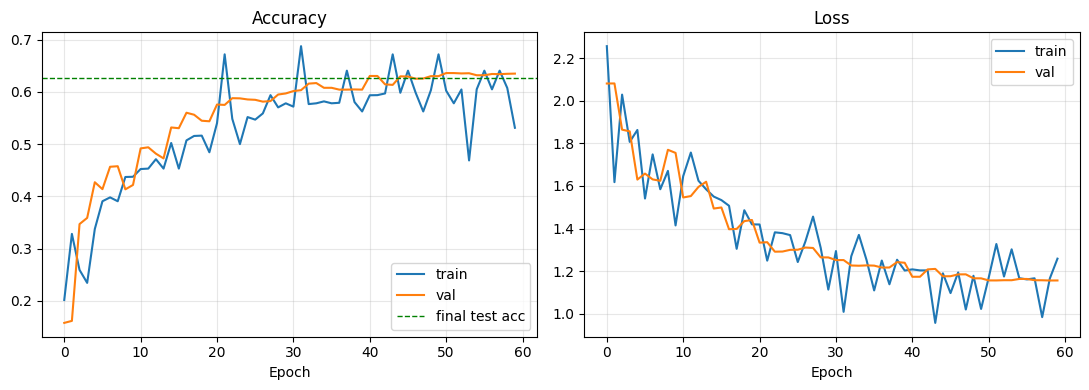

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11,4))

ax[0].plot(history.history['accuracy'], label='train')
ax[0].plot(history.history['val_accuracy'], label='val')
ax[0].axhline(test_acc, color='green', ls='--', lw=1, label='final test acc')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(history.history['loss'], label='train')
ax[1].plot(history.history['val_loss'], label='val')
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=130)
plt.show()

## 9. Download the trained model

In [23]:
from google.colab import files
files.download('emotion_model.h5')
files.download('training_curves.png')
print("Downloaded! Drop emotion_model.h5 into your local emotion-detector/models/ folder")
print("and run: python src/realtime_app.py --model models/emotion_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded! Drop emotion_model.h5 into your local emotion-detector/models/ folder
and run: python src/realtime_app.py --model models/emotion_model.h5
